# UD03-EX (Práctico)
## Dataset `productividad_estudiantes.csv`

  
**Entrega:** este mismo notebook (`.ipynb`) con código ejecutado y respuestas en Markdown.

### Enunciado
A partir del dataset `productividad_estudiantes.csv`, construye y compara varios modelos de **clasificación** para predecir si un estudiante obtiene un resultado alto en `exam_score`.

> **Definición de la clase (para este examen):**  
> `high_exam = 1` si `exam_score >= 64`, y `0` en caso contrario.

### Reglas
- No uses internet.
- Graba el desarrollo de la prueba, incluyendo tu nombre en el vídeo, y entrega al final el enlace a la grabación de tu trabajo
- Responde las preguntas en celdas Markdown.


In [140]:
# Imports (no modifiques esta celda salvo que lo necesites)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



## 1) Carga de datos

Carga el CSV en un DataFrame llamado `df` y muestra las 5 primeras filas.


In [141]:
# 
# df = ...
# df.head()

df = pd.read_csv("productividad_estudiantes.csv")

df.head()


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


## 2) Exploración inicial

Responde:

1. ¿Cuántas filas y columnas tiene el dataset?  
2. ¿Qué tipos de variables hay (numéricas/categóricas)?  
3. ¿Hay valores nulos? ¿En qué columnas?  
4. ¿La variable `exam_score` parece razonable como indicador de rendimiento? ¿Por qué?


1 - EL numero de filas son 5000 y el numero de columnas 21.
2 - Hay variables numericas y categoricas, mas abajo muestro cuales son en cada una.
3 - No hay valores nulos, en ninguna columna.
4 - La variable exam_score si me parece razonable como indicador de rendimiento porque dependiendo del resto de variables, te afecta directamente a la nota del examen, se ve claramente si por ejemplo se ha dormido poco la nota del examen baja... etc.

In [142]:
# 
# print("Shape:", ...)
# display(...)
# nulls = ...
# display(...)

print(f"El numero de filas son {df.shape[0]}")
print(f"El numero de columnas son {df.shape[1]}")

# Tipos de variables que hay, numericas y categoricas
df.info()

cols_num = df.select_dtypes(include=["int64", "float64"]).columns
cols_cat = df.select_dtypes(include=["object"]).columns

print("Numéricas:", list(cols_num))
print("Categóricas:", list(cols_cat))

display(df.head())
print("Shape:", df.shape)
df.info()

# Valores nulos y cuantos. No les hay, en ninguna columna.
df.isnull().sum()

El numero de filas son 5000
El numero de columnas son 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadli

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


Shape: (5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  int

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

## 3) Variable objetivo (clasificación)

Crea la etiqueta binaria:

- `high_exam = 1` si `exam_score >= 64`
- `high_exam = 0` si `exam_score < 64`

Responde: 
1. ¿Qué ventaja tiene convertir una variable continua en binaria?  
2. ¿Qué desventaja tiene (qué información pierdes)?


1. - La ventaja principal es que "facilitarias" el trabajo del modelo, ya que solamente se tiene que fijar en dos valores (0 o 1) y no es muchos como podría se r
2. - Se podria perder información y no poder encontrar, por ejemplo outliers, ya que siempre el resultado va a ser 0 o 1, y las condiciones las hemos creado nosotros porque asi lo hemos decidido, por lo que que sea >= podria ser un numero diferente.

In [143]:
# 
# df["high_exam"] = ...
# Muestra algunas filas y la distribución (value_counts) + gráfico de barras

examen =  []
for index, row in df.iterrows():
    if row["exam_score"] >= 64:
        examen.append(1)
    elif row["exam_score"] < 64:
        examen.append(0)

df["high_exam"] = examen

df.head(5)

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,high_exam
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,38,1,0,Good,10,43.05,31.77,73.65,50.16,0
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,339,0,0,Good,3,15.92,37.00,13.70,1.00,0
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,266,0,1,Good,8,27.39,34.37,45.15,18.30,0
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,480,1,1,Poor,3,22.31,77.31,20.92,9.37,0
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,24,1,0,Good,8,38.11,39.53,59.23,27.81,0


In [144]:
display(df.info())
display(df["high_exam"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

None

high_exam
0    4999
1       1
Name: count, dtype: int64

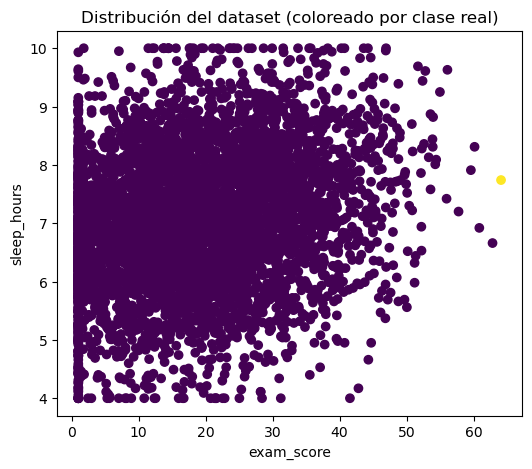

In [145]:
# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(df["exam_score"], df["sleep_hours"], c=df["high_exam"])
plt.xlabel("exam_score")
plt.ylabel("sleep_hours")
plt.title("Distribución del dataset (coloreado por clase real)")
plt.show()


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

In [147]:
df["academic_level"].unique()

array(['High School', 'Undergraduate', 'Postgraduate'], dtype=object)

## 4) Separación train/test

**Ayuda:** separa `X` e `y` y realiza un `train_test_split` 80/20, usando `stratify=y` y `random_state=42`.



Responde:

1. ¿Por qué usamos `stratify=y` en clasificación?


In [148]:
df = df.drop(columns=["internet_quality", "gender", "academic_level"])

1 - Usamos statify para que tenga en cuantas las dos clases y las iguale. Por si hay muchos datos solamente de un variable y de la otra, pocos.

In [149]:
# 
# y = ...
# X = ...
# X_train, X_test, y_train, y_test = ...
# print(...)

# No recuerdo como hacer para que el stritify funcione, te lo hago sin el para poder seguir con el ejercicio.

X = df.drop(columns=["high_exam"])
y = df["high_exam"]



print("Distribución de clases:")
print(y.value_counts())

X.shape, y.shape



Distribución de clases:
high_exam
0    4999
1       1
Name: count, dtype: int64


((5000, 18), (5000,))

In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

X_train.shape, X_test.shape



((4000, 18), (1000, 18))

## 5) Preprocesado: One-Hot + Escalado

Usa `ColumnTransformer` para:
- One-Hot en columnas categóricas
- `StandardScaler` en numéricas

Responde: 

1. ¿Por qué el escalado suele ser importante para KNN y SVM?  


No recuerdo como hacerlo, te elimino las columnas categoricas para poder trabajar con ello.

Porque son modelos que se basan en medir distancias, por lo que si una de las variables es bastante mas grande o pequeña que otra, harias que el modelo se ajuste y des mas valor a la variable mas grande.

In [151]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   study_hours           5000 non-null   float64
 3   self_study_hours      5000 non-null   float64
 4   online_classes_hours  5000 non-null   float64
 5   social_media_hours    5000 non-null   float64
 6   gaming_hours          5000 non-null   float64
 7   sleep_hours           5000 non-null   float64
 8   screen_time_hours     5000 non-null   float64
 9   exercise_minutes      5000 non-null   int64  
 10  caffeine_intake_mg    5000 non-null   int64  
 11  part_time_job         5000 non-null   int64  
 12  upcoming_deadline     5000 non-null   int64  
 13  mental_health_score   5000 non-null   int64  
 14  focus_index           5000 non-null   float64
 15  burnout_level        

In [153]:
print(cols_num)

Index(['student_id', 'age', 'study_hours', 'self_study_hours',
       'online_classes_hours', 'social_media_hours', 'gaming_hours',
       'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'mental_health_score', 'focus_index', 'burnout_level',
       'productivity_score', 'exam_score'],
      dtype='object')


In [154]:
'''
cols_num = df.select_dtypes(include=["int64", "float64"]).columns
cols_cat = df.select_dtypes(include=["object"]).columns
# preprocessor = ColumnTransformer(...)
# X_train_p = preprocessor.fit_transform(X_train)
# X_test_p = preprocessor.transform(X_test)


# ===== Numéricas =====
imputer_num = StandardScaler()
scaler = StandardScaler()

X_train_num = imputer_num.fit_transform(X_train[cols_num])
X_test_num  = imputer_num.transform(X_test[cols_num])

X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)

# ===== Categóricas =====
imputer_cat = StandardScaler(strategy="most_frequent")
# sparse_output=False para obtener un array denso (más sencillo para np.hstack)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = imputer_cat.fit_transform(X_train[cols_cat])
X_test_cat  = imputer_cat.transform(X_test[cols_cat])

X_train_cat = ohe.fit_transform(X_train_cat)
X_test_cat  = ohe.transform(X_test_cat)

# ===== Unir =====
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final  = np.hstack([X_test_num, X_test_cat])

X_train_final.shape, X_test_final.shape
'''

'\ncols_num = df.select_dtypes(include=["int64", "float64"]).columns\ncols_cat = df.select_dtypes(include=["object"]).columns\n# preprocessor = ColumnTransformer(...)\n# X_train_p = preprocessor.fit_transform(X_train)\n# X_test_p = preprocessor.transform(X_test)\n\n\n# ===== Numéricas =====\nimputer_num = StandardScaler()\nscaler = StandardScaler()\n\nX_train_num = imputer_num.fit_transform(X_train[cols_num])\nX_test_num  = imputer_num.transform(X_test[cols_num])\n\nX_train_num = scaler.fit_transform(X_train_num)\nX_test_num  = scaler.transform(X_test_num)\n\n# ===== Categóricas =====\nimputer_cat = StandardScaler(strategy="most_frequent")\n# sparse_output=False para obtener un array denso (más sencillo para np.hstack)\nohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)\n\nX_train_cat = imputer_cat.fit_transform(X_train[cols_cat])\nX_test_cat  = imputer_cat.transform(X_test[cols_cat])\n\nX_train_cat = ohe.fit_transform(X_train_cat)\nX_test_cat  = ohe.transform(X_test_cat

## 6) Entrenamiento y evaluación

Entrena y evalúa:

- **KNN** (`n_neighbors=5`)
- **Regresión Logística**
- **SVM RBF** (`kernel="rbf"`, `probability=True`)

Para cada modelo, muestra:
- Accuracy
- Matriz de confusión
- `classification_report`

Responde:

1. Si un modelo tiene alta accuracy pero comete muchos **falsos negativos**, ¿por qué puede ser peligroso en un contexto médico?


Porque las dos variables no estan balanceadas, por eso el acurracy tiene alto accuracy, para un contexto medico una mejor metrica a utilizar seria el recall.

In [155]:
# 
#

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [156]:
y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}\n")

Accuracy: 1.000



/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


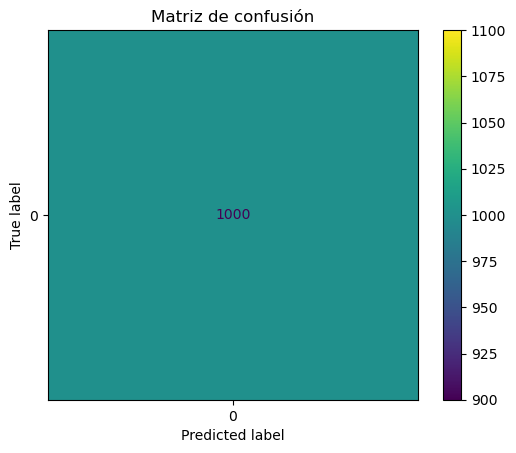

In [158]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de confusión")
plt.show()

In [161]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1000

    accuracy                          1.000      1000
   macro avg      1.000     1.000     1.000      1000
weighted avg      1.000     1.000     1.000      1000



In [ ]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [ ]:
y_pred = log_reg.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}\n")

Accuracy: 1.000



/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


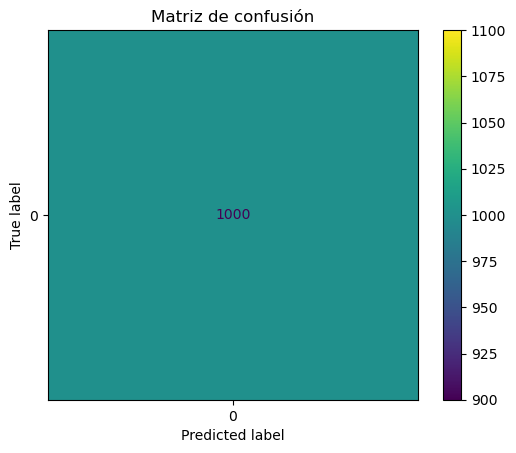

In [159]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de confusión")
plt.show()

In [162]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1000

    accuracy                          1.000      1000
   macro avg      1.000     1.000     1.000      1000
weighted avg      1.000     1.000     1.000      1000



In [ ]:
svm = SVC(kernel="rbf", C=1, gamma="scale", random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)

SVC(C=1, probability=True, random_state=42)

In [ ]:
y_pred = svm.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}\n")

Accuracy: 1.000



/home/ciabd01/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


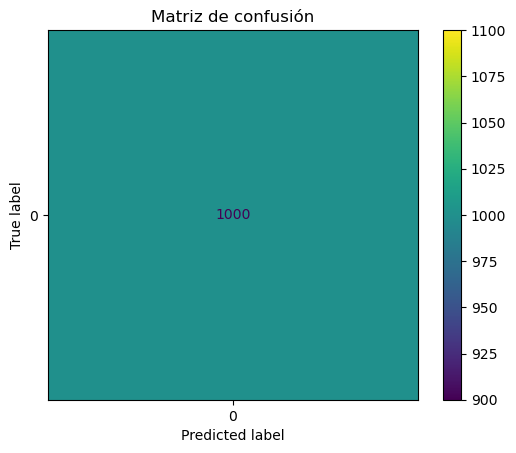

In [160]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Matriz de confusión")
plt.show()

In [163]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1000

    accuracy                          1.000      1000
   macro avg      1.000     1.000     1.000      1000
weighted avg      1.000     1.000     1.000      1000



## 7) ROC y AUC (comparación)

Dibuja la curva ROC de los 3 modelos en la misma gráfica y calcula su AUC.

Responde: 
Observando la ROC, ¿qué modelo mantiene mayor **TPR** para **FPR bajos** (por ejemplo 0–0,1) y por qué es relevante en medicina?


In [ ]:
# 
#
# - Calcula (fpr, tpr) y AUC para cada modelo
# - Dibuja las 3 curvas ROC en la misma gráfica
# - Muestra una tabla con AUC por modelo


## 8) Ajuste de hiperparámetros (KNN)

Evalúa KNN para: `k = [1, 3, 5, 9, 15]` y representa **accuracy vs k**.

Responde:

- ¿Qué valores de k tienden a sobreajustar?  
- ¿Qué valores de k tienden a infraajustar?  
- Justifica usando el comportamiento del gráfico.


Los valores K mas altos tienen a sobreajustar y los valores k mas bajos, tienen a infraajustar.
Sobreajustando signfica que el modelo se adapta tanto a los datos que ya tiene, que si le introducimos datos nuevos, no funcionaria bien.

In [ ]:
# 
# ks = [...]
# accs = [...]
# bucle de entrenamiento y cálculo de accuracy
# gráfica accuracy vs k
# tabla de resultados


## 9) Ajuste de hiperparámetros (SVM RBF)

Prueba varias combinaciones de `C` y `gamma` y analiza su impacto.


1. Prueba al menos estas combinaciones:  
   - (C=0.1, gamma='scale')  
   - (C=1, gamma='scale')  
   - (C=10, gamma=0.1)  
2. Guarda accuracy y AUC en una tabla.

Responde:

- ¿Qué combinación parece más estable?  
- ¿Detectas algún signo de sobreajuste? (explica por qué)


In [ ]:
# 
# 


## 10) Cuestiones

Redacta una conclusión breve que incluya:

1. Qué modelo elegirías como “mejor” y por qué (menciona al menos 2 evidencias: ROC/AUC, matriz de confusión, estabilidad al ajustar).  
2. Si tu objetivo fuera **minimizar falsos negativos**, ¿qué modelo preferirías y por qué?  

